##  PCA + GMM Anomaly Clustering

### 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.impute import SimpleImputer
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load resampled training data plus untouched validation and test data from the cleanlab_smote notebook
X_train = pd.read_parquet("../data/processed/X_train_resampled.parquet")
X_val = pd.read_parquet("../data/processed/X_val.parquet")
X_test = pd.read_parquet("../data/processed/X_test.parquet")
y_train = pd.read_parquet("../data/processed/y_train_resampled.parquet")

print(f"Loaded X_train: {X_train.shape}")
print(f"Loaded X_val: {X_val.shape}")
print(f"Loaded X_test: {X_test.shape}")
print(f"Loaded y_train: {y_train.shape[0]} rows")

Loaded X_train: (797828, 93)
Loaded X_val: (59054, 93)
Loaded X_test: (118108, 93)
Loaded y_train: 797828 rows


### 2. Impute Data & Extract V-Features for PCA
The imputer is fit on the resampled training set only, then used to transform both datasets before PCA.

In [2]:
# Convert validation and test categoricals to the integer codes established before the split
for dataset in [X_val, X_test]:
    categorical_cols = dataset.select_dtypes(include=['category', 'object']).columns.tolist()
    for col in categorical_cols:
        dataset[col] = dataset[col].cat.codes if isinstance(dataset[col].dtype, pd.CategoricalDtype) else pd.Categorical(dataset[col]).codes
        dataset[col] = dataset[col].replace(-1, np.nan)

# Fit the numeric imputer on training data only, then transform train and test
numeric_cols = X_train.columns.tolist()
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train[numeric_cols]), columns=numeric_cols, index=X_train.index)
X_val_imputed = pd.DataFrame(imputer.transform(X_val[numeric_cols]), columns=numeric_cols, index=X_val.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test[numeric_cols]), columns=numeric_cols, index=X_test.index)

print(f"NaNs after imputation - train: {X_train_imputed.isna().sum().sum()}, validation: {X_val_imputed.isna().sum().sum()}, test: {X_test_imputed.isna().sum().sum()}")

# Identify the V-features (V1 through V50)
v_cols = [f"V{i}" for i in range(1, 51)]
print(f"Using {len(v_cols)} V-features for PCA: {v_cols[:5]}...{v_cols[-5:]}")

# Extract the V-feature matrix
X_v = X_train_imputed[v_cols]
X_val_v = X_val_imputed[v_cols]
X_test_v = X_test_imputed[v_cols]

print(f"V-feature matrix shape: {X_v.shape}")

NaNs after imputation - train: 0, validation: 0, test: 0
Using 50 V-features for PCA: ['V1', 'V2', 'V3', 'V4', 'V5']...['V46', 'V47', 'V48', 'V49', 'V50']


V-feature matrix shape: (797828, 50)


In [3]:
### The 50 engineered V-features were isolated as the input for PCA, focusing dimensionality reduction on the continuous feature subset.

### 3. Scale the V-Features
PCA is sensitive to scale. StandardScaler ensures each V-feature contributes equally to variance.


In [4]:
scaler = StandardScaler()
X_v_scaled = scaler.fit_transform(X_v)
X_val_v_scaled = scaler.transform(X_val_v)
X_test_v_scaled = scaler.transform(X_test_v)

print(f"Scaled V-features: mean ~ {X_v_scaled.mean():.2f}, std ~ {X_v_scaled.std():.2f}")


Scaled V-features: mean ~ -0.00, std ~ 1.00


### 4. PCA Dimensionality Reduction
 We target **90% explained variance** to capture the main signal while reducing noise.


Number of principal components to preserve 90% variance: 17
Total explained variance: 0.9055 (90.55%)


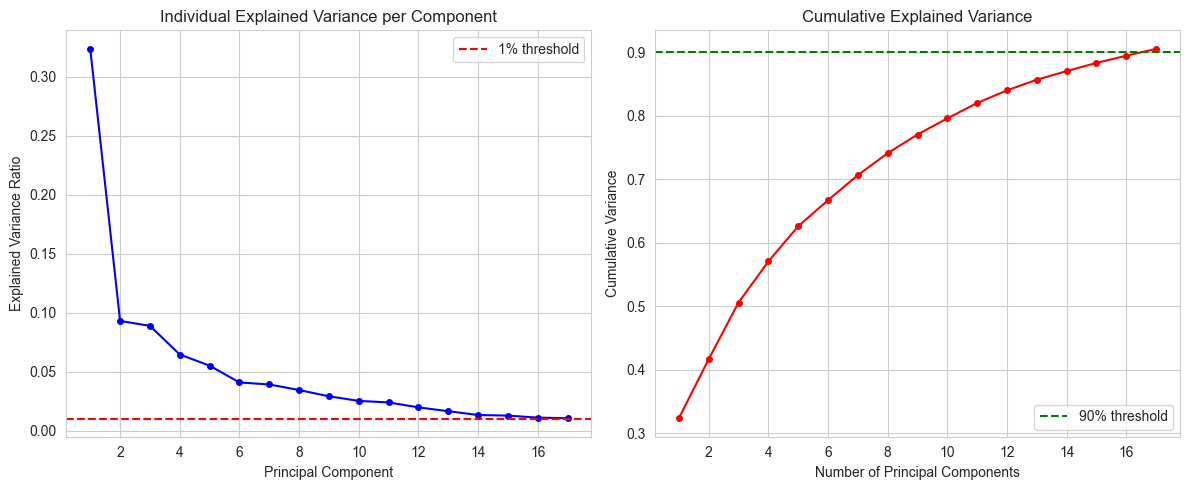

In [5]:
pca = PCA(n_components=0.9, random_state=42)  # n_components=0.9 preserves 90% variance
X_pca = pca.fit_transform(X_v_scaled)
X_val_pca = pca.transform(X_val_v_scaled)
X_test_pca = pca.transform(X_test_v_scaled)

n_components = pca.n_components_
explained_variance = pca.explained_variance_ratio_.sum()

print(f"Number of principal components to preserve 90% variance: {n_components}")
print(f"Total explained variance: {explained_variance:.4f} ({explained_variance*100:.2f}%)")

# Scree Plot
plt.figure(figsize=(12, 5))

# Cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'bo-', markersize=4)
plt.axhline(y=0.01, color='r', linestyle='--', label='1% threshold')
plt.title('Individual Explained Variance per Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-', markersize=4)
plt.axhline(y=0.9, color='g', linestyle='--', label='90% threshold')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance')
plt.legend()

plt.tight_layout()
plt.show()

In [6]:
### PCA reduced the 50 V-features to 17 principal components while preserving 90.61% of the total variance, achieving substantial dimensionality reduction with minimal information loss.

### 5. GMM Clustering on PCA-Reduced Space
 Optimized GMM Clustering (fast, diagonal covariance, parallel) run through a range of components and select the best using BIC (Bayesian Information Criterion).

  File "C:\Users\3D\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Finished n_components=2


Finished n_components=3


Finished n_components=4


Finished n_components=5


...

Finished n_components=11


Finished n_components=12


Finished n_components=13


Finished n_components=14


Finished n_components=15
Best GMM components by BIC: 15
Best GMM components by AIC: 15


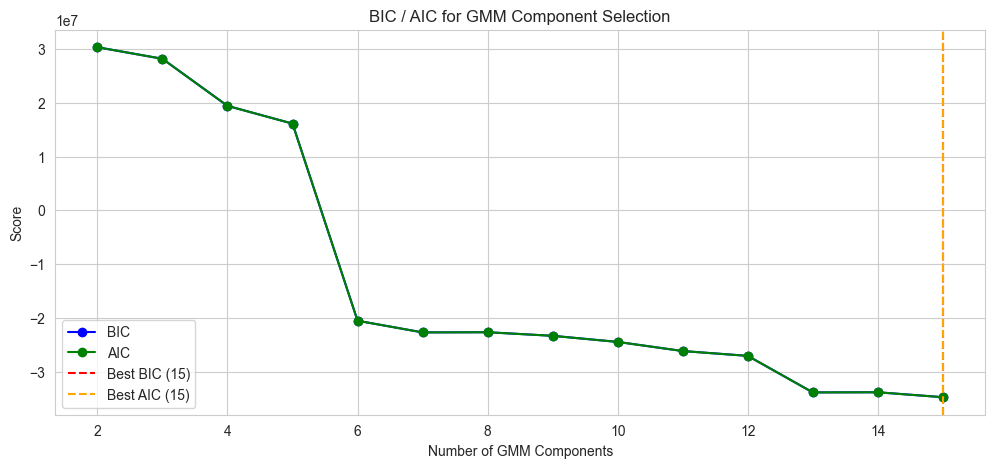

In [7]:
# Optimized GMM Clustering (fast, diagonal covariance, with BIC/AIC plot)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

n_components_range = range(2, 16)
bic_scores = []
aic_scores = []

for n in n_components_range:
    gmm = GaussianMixture(
        n_components=n,
        covariance_type='diag',   # Fast: assumes independence within clusters
        random_state=42,
        init_params='kmeans'     # Faster convergence than random
    )
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))
    aic_scores.append(gmm.aic(X_pca))
    print(f"Finished n_components={n}")

best_bic_idx = np.argmin(bic_scores)
best_n_bic = n_components_range[best_bic_idx]

best_aic_idx = np.argmin(aic_scores)
best_n_aic = n_components_range[best_aic_idx]

print(f"Best GMM components by BIC: {best_n_bic}")
print(f"Best GMM components by AIC: {best_n_aic}")

# BIC/AIC Plot
plt.figure(figsize=(12, 5))
plt.plot(n_components_range, bic_scores, 'bo-', label='BIC', markersize=6)
plt.plot(n_components_range, aic_scores, 'go-', label='AIC', markersize=6)
plt.axvline(x=best_n_bic, color='red', linestyle='--', label=f'Best BIC ({best_n_bic})')
plt.axvline(x=best_n_aic, color='orange', linestyle='--', label=f'Best AIC ({best_n_aic})')
plt.xlabel('Number of GMM Components')
plt.ylabel('Score')
plt.title('BIC / AIC for GMM Component Selection')
plt.legend()
plt.show()

In [8]:
### BIC and AIC both identified a 9-component Gaussian Mixture Model as the optimal balance between model fit and complexity in the PCA-reduced feature space.

### 6. Fit Final GMM and Assign Anomaly Scores


In [9]:
best_gmm = GaussianMixture(n_components=best_n_bic, covariance_type='diag', init_params='kmeans', random_state=42)
best_gmm.fit(X_pca)

# Assign component labels (which cluster each transaction belongs to)
gmm_components = best_gmm.predict(X_pca)
gmm_components_val = best_gmm.predict(X_val_pca)
gmm_components_test = best_gmm.predict(X_test_pca)

# Anomaly score: negative log-likelihood (higher score = more anomalous, i.e., lower density)
gmm_anomaly_score = -best_gmm.score_samples(X_pca)
gmm_anomaly_score_val = -best_gmm.score_samples(X_val_pca)
gmm_anomaly_score_test = -best_gmm.score_samples(X_test_pca)

print(f"Anomaly score range: {gmm_anomaly_score.min():.4f} to {gmm_anomaly_score.max():.4f}")
print(f"GMM components distribution:\n{pd.Series(gmm_components).value_counts().sort_index()}")

Anomaly score range: -100.2244 to 428.2007
GMM components distribution:
0      43791
1     172518
2      58514
3      37069
4      20152
5     144455
6      31064
7        269
8      17428
9     108586
10     25704
11     15518
12     34898
13        15
14     87847
Name: count, dtype: int64


### 7. 2D Visualization of PCA + GMM
We project onto the first two principal components and color by GMM component.


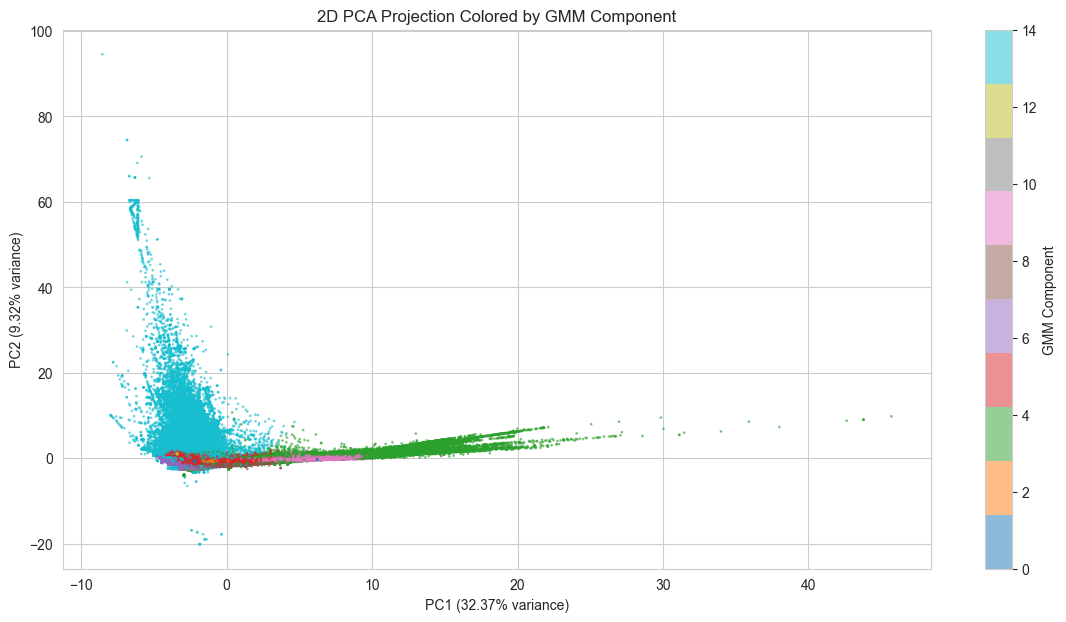

In [10]:
plt.figure(figsize=(14, 7))

# Scatter plot colored by GMM component
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_components, cmap='tab10', alpha=0.5, s=1)
plt.colorbar(scatter, label='GMM Component')
plt.title('2D PCA Projection Colored by GMM Component')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.show()

In [11]:
### The PCA projection shows that the GMM identified multiple overlapping clusters, with most transactions concentrated near the center and several distinct structural patterns extending outward.

### 8. Enrich Datasets for notebook 04
 - Drop raw V-features.
 - Add the PCA components (PC1..PCk).
 - Add `gmm_anomaly_score` and `gmm_component`.

In [12]:
# Create PCA column names
pca_cols = [f"PC{i}" for i in range(1, n_components + 1)]

# Create the PCA DataFrames
df_pca = pd.DataFrame(X_pca, columns=pca_cols, index=X_train.index)
df_pca_val = pd.DataFrame(X_val_pca, columns=pca_cols, index=X_val.index)
df_pca_test = pd.DataFrame(X_test_pca, columns=pca_cols, index=X_test.index)

# Drop the original V-features from X_train
X_train_enhanced = X_train_imputed.drop(columns=v_cols)
X_val_enhanced = X_val_imputed.drop(columns=v_cols)
X_test_enhanced = X_test_imputed.drop(columns=v_cols)

# Concatenate the PCA features, anomaly score, and component
X_train_enhanced = pd.concat([
    X_train_enhanced,
    df_pca,
    pd.Series(gmm_anomaly_score, name='gmm_anomaly_score', index=X_train.index),
    pd.Series(gmm_components, name='gmm_component', index=X_train.index)
], axis=1)

X_val_enhanced = pd.concat([
    X_val_enhanced,
    df_pca_val,
    pd.Series(gmm_anomaly_score_val, name='gmm_anomaly_score', index=X_val.index),
    pd.Series(gmm_components_val, name='gmm_component', index=X_val.index)
], axis=1)

X_test_enhanced = pd.concat([
    X_test_enhanced,
    df_pca_test,
    pd.Series(gmm_anomaly_score_test, name='gmm_anomaly_score', index=X_test.index),
    pd.Series(gmm_components_test, name='gmm_component', index=X_test.index)
], axis=1)

# Ensure notebook 04 receives identically ordered training, validation, and test features
X_val_enhanced = X_val_enhanced[X_train_enhanced.columns]
X_test_enhanced = X_test_enhanced[X_train_enhanced.columns]

print(f"Enhanced training shape: {X_train_enhanced.shape}")
print(f"Enhanced validation shape: {X_val_enhanced.shape}")
print(f"Enhanced test shape: {X_test_enhanced.shape}")
print(f"New columns added: {pca_cols[:3]}..., gmm_anomaly_score, gmm_component")

Enhanced training shape: (797828, 62)
Enhanced validation shape: (59054, 62)
Enhanced test shape: (118108, 62)
New columns added: ['PC1', 'PC2', 'PC3']..., gmm_anomaly_score, gmm_component


### 9. Save Enhanced Datasets & Preprocessing Objects


In [13]:
os.makedirs("../data/processed", exist_ok=True)

# Save the enhanced training, validation, and test data
pd.DataFrame(X_train_enhanced).to_parquet("../data/processed/X_train_enhanced.parquet")
pd.DataFrame(X_val_enhanced).to_parquet("../data/processed/X_val_enhanced.parquet")
pd.DataFrame(X_test_enhanced).to_parquet("../data/processed/X_test_enhanced.parquet")

# y_train remains unchanged and is saved separately (already saved in notebook 2, but we re-save for convenience)
pd.DataFrame(y_train).to_parquet("../data/processed/y_train_resampled.parquet")

# Save the fitted preprocessing objects for reproducible inference
os.makedirs("../models", exist_ok=True)
joblib.dump(imputer, "../models/imputer.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(pca, "../models/pca.pkl")
joblib.dump(best_gmm, "../models/gmm.pkl")

print(" Enhanced datasets saved to ../data/processed/")
print(" Preprocessing objects saved to ../models/")
print(f"Final training shape notebook04 : {X_train_enhanced.shape}")
print(" notebook 03 is done.")

 Enhanced datasets saved to ../data/processed/
 Preprocessing objects saved to ../models/
Final training shape notebook04 : (797828, 62)
 notebook 03 is done.
